# Mini Introduction

A small introduction on how to work with the BAMBI dataset.
Note, this tutorial does not cover all aspects neither of the [replication package](https://github.com/bambi-eco/Dataset), nor of our geospatial packages [bambi-detection](https://github.com/bambi-eco/bambi_detection) or [ALFSPY](https://github.com/bambi-eco/alfs_py).

## Clone Repository

In [1]:
!git clone https://github.com/bambi-eco/Dataset.git

Cloning into 'Dataset'...
remote: Enumerating objects: 604, done.
remote: Counting objects: 100% (604/604), done.
remote: Compressing objects: 100% (84/84), done.
remote: Total 604 (delta 551), reused 567 (delta 516), pack-reused 0 (from 0)
Receiving objects: 100% (604/604), 159.63 KiB | 5.50 MiB/s, done.
Resolving deltas: 100% (551/551), done.


## Filter flights
Filter the flights based on the available labels e.g. looking for roe deer, red deer and wild boar

In [8]:
!python Dataset/filter_flights.py --folder Dataset/flight_metadata/ --species "Roe deer" "Red deer" "Wild boar"

Applied filters:
------------------------------------------------------------
  Species:    Roe deer, Red deer, Wild boar  (OR, substring match)

['0', '100', '101', '102', '103', '104', '105', '106', '10', '111', '112', '113', '114', '115', '116', '117', '118', '119', '120', '121', '122', '123', '124', '129', '130', '131', '132', '134', '135', '136', '137', '138', '139', '13', '140', '141', '142', '143', '144', '145', '146', '147', '148', '149', '14', '150', '151', '152', '155', '156', '158', '159', '15', '160', '161', '162', '163', '16', '175', '176', '177', '178', '179', '17', '180', '181', '182', '183', '184', '185', '186', '187', '188', '189', '18', '190', '191', '192', '193', '194', '195', '196', '197', '198', '199', '1', '200', '201', '202', '203', '204', '205', '206', '207', '209', '20', '210', '211', '212', '213', '215', '216', '21', '221', '222', '223', '224', '225', '226', '227', '228', '229', '22', '230', '231', '232', '234', '235', '236', '237', '238', '239', '240', '241',

## Download flights of interest
Download the flights based on the ID retrieved via the filter (or without -f to get all flights) and unzip the content. In below's example only download flight 146.

In [2]:
!python Dataset/download_from_zenodo.py -s Dataset/flight_metadata/zenodo_upload_summary.json -f 146 --unzip


📥 Downloading 1 flight(s) from 1 deposition(s)
📦 ZIPs will be extracted and removed after download

──────────────────────────────────────────────────
  Part 3 (deposition 18703312)
  ⬇  flight_146.zip
     430.3 / 430.3 MB (100%)
     📦 Extracted 8 file(s), ZIP removed

──────────────────────────────────────────────────
✅ Done! Downloaded: 1, Skipped: 0, Extracted: 1
   Files saved to /content/bambi_downloads


## Interpolate MOT labels
The data is labelled using multi-object tracks using a key-frame approach.
To get labels for every single video frame between key-frames, we have to interpolate them.

In [9]:
!python Dataset/mot_interpolation.py bambi_downloads interpolated_mot

Processing 1 file(s), step=1
Output folder: interpolated_mot

  146_gt.txt: 240 original + 3213 interpolated = 3453 total detections

Done.


## Extract frames and visualize labels
Extract some RGB and thermal frames from the split videos.

In [4]:
!python Dataset/frame_extraction.py bambi_downloads/146_matched_processed.mp4 146_frames --start 2120 --end 2130

  Video: 146_matched_processed.mp4
  ID: 146  MOT: 146_gt.txt
  Resolution: 2048x1024 (each half: 1024x1024)
  Total frames: 12191, FPS: 29.97
  Frame range: 2120 to 2130 (exclusive)
  Sample rate: every 1 frame(s)
  Naming: 146_<frame_idx>.png
  MOT: 0 annotations -> 146_gt.txt
  Done: 10 frames exported.



Add the bounding boxes to one example thermal and one example RGB frame.

In [5]:
!python Dataset/mot_frame_viewer.py 146_frames/thermal/146_00002120.png interpolated_mot/146_gt.txt -o 146_00002120_vis_thermal.png

Frame index: 2120
Found 6 exact + 0 interpolated detections for frame 2120 (total 3453 detections, 12 tracks in file)
Saved: 146_00002120_vis_thermal.png


In [6]:
!python Dataset/mot_frame_viewer.py 146_frames/rgb/146_00002120.png interpolated_mot/146_gt.txt -o 146_00002120_vis_rgb.png

Frame index: 2120
Found 6 exact + 0 interpolated detections for frame 2120 (total 3453 detections, 12 tracks in file)
Saved: 146_00002120_vis_rgb.png


Visualize the bounding boxes on top of the two example frames.
(Note the small temporal offsets between the modalities. To match frames you need a matching strategy as proposed [here](https://github.com/HugoMarkoff/BAMBI_BBox_Corrections))

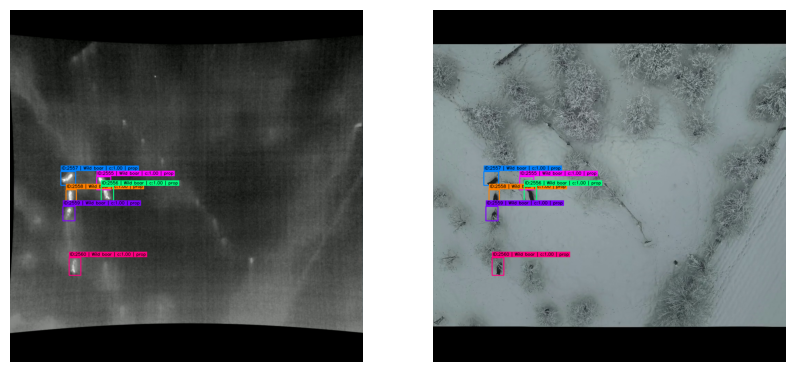

In [7]:
import matplotlib.pyplot as plt
from PIL import Image

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(Image.open("146_00002120_vis_thermal.png"))
axes[1].imshow(Image.open("146_00002120_vis_rgb.png"))

for ax in axes:
    ax.axis("off")

plt.subplots_adjust(wspace=0.2)
plt.show()